#### 챔피언별 승률 기준으로 이상치 찾기
- Isolation Forest

In [5]:
# 데이터 호출
import pandas as pd

df_champion = pd.read_csv('../../유저단위_게임데이터_상위랭커보존-stats_champion_1.csv')


In [6]:
print(df_champion.info())

display(df_champion.head(1))

<class 'pandas.DataFrame'>
RangeIndex: 396204 entries, 0 to 396203
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   user_id           396204 non-null  str  
 1   game_id           396204 non-null  str  
 2   user_tier         396204 non-null  str  
 3   ranked            396204 non-null  int64
 4   flag_1            396204 non-null  int64
 5   flag_2            396204 non-null  int64
 6   active_synergies  396204 non-null  str  
 7   top4_flag         396204 non-null  bool 
 8   ranked_1          396204 non-null  bool 
 9   champions         396204 non-null  str  
dtypes: bool(2), int64(3), str(5)
memory usage: 24.9 MB
None


,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,champions
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,"[{'name': 'ziggs', 'star': 1, 'cost': 1, 'orig..."


In [7]:
# gameid별 유저 수 확인
game_user_count = df_champion.groupby('game_id')['user_id'].nunique()

# 8명이 참여한 게임만 추출
valid_games = game_user_count[game_user_count == 8].index

# 필터링
df_champ_valid = df_champion[df_champion['game_id'].isin(valid_games)]

print(f'전체 게임 수: {df_champion["game_id"].nunique()}')
print(f'8명 풀게임 수: {df_champ_valid["game_id"].nunique()}')
print(f'필터링 후, 행 수: {len(df_champ_valid)}')

전체 게임 수: 49562
8명 풀게임 수: 49339
필터링 후, 행 수: 394712


In [8]:
import ast

# champions 컬럼 문자열 → 리스트로 변환
df_champ_valid['champions'] = df_champ_valid['champions'].apply(ast.literal_eval)

# 챔피언 단위로 explode
df_champ_valid_exploded = df_champ_valid.explode('champions')

# 딕셔너리 컬럼 분리
df_champ_valid_exploded = pd.concat([
    df_champ_valid_exploded.drop(columns='champions'),
    df_champ_valid_exploded['champions'].apply(pd.Series)
], axis=1)

print(df_champ_valid_exploded.shape)
display(df_champ_valid_exploded.head(2))

(3119788, 14)


,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,name,star,cost,origin,class
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,ziggs,1,1,Rebel,['Demolitionist']
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,ashe,1,3,Celestial,['Sniper']


In [9]:
# 전체 유저-게임 수 (8명 풀게임 기준)
total_user_games_champ = len(df_champ_valid[['game_id', 'user_id']].drop_duplicates())

# 챔피언별 통계 집계
champ_stats_valid = df_champ_valid_exploded.groupby(['name', 'cost']).agg(
    pick_count=('name', 'count'),
    avg_rank=('ranked', 'mean'),
    win_rate=('ranked_1', 'mean'),
    top4_rate=('top4_flag', 'mean')
).reset_index()

# 픽률 계산
champ_stats_valid['pick_rate'] = champ_stats_valid['pick_count'] / total_user_games_champ

display(champ_stats_valid.head(5))

,name,cost,pick_count,avg_rank,win_rate,top4_rate,pick_rate
0,ahri,2,36340,4.578233,0.131233,0.485526,0.092067
1,annie,2,52402,4.446758,0.134441,0.509790,0.132760
2,ashe,3,88819,4.390772,0.131976,0.517682,0.225022
3,aurelionsol,5,23044,3.539924,0.199488,0.688422,0.058382
4,blitzcrank,2,119665,4.413730,0.118238,0.516826,0.303170


In [10]:
champ_stats_valid.to_csv('./champions_stats_by_full_game(ML).csv', index=False, encoding='utf-8-sig')

---

#### Isolation_Forest를 사용해서 이상치 탐색하기

##### Isolation_Forest에서 피처의 의미

- 피처로 선택한 변수들을 기준으로 "다른 데이터와 얼마나 다른가"를 측정
- 피처가 많을수록 → 여러 변수를 종합해서 이상치 판단
- 피처가 적을수록 → 특정 변수에 집중해서 이상치 판단

In [18]:
# 라이브러리 호출
from sklearn.ensemble import IsolationForest


random_seed = 42

In [19]:
# 피처 선택
X_champ = champ_stats_valid[['win_rate', 'pick_rate']]

In [20]:
# Isolation_Forest 모델 정의
iso_forest_champ = IsolationForest(
    contamination=0.05,
    random_state=42
)

# anomaly: Isolation Forest가 각 데이터를 분류한 결과
    # 1 → 정상 (다른 시너지들과 비슷한 패턴)
    # -1 → 이상치 (다른 시너지들과 패턴이 다름)
    
# anomaly_score: 각 데이터가 얼마나 이상치에 가까운지를 나타내는 점수
    # 0에 가까울수록 → 정상
    # 음수일수록 → 이상치에 가까움

In [21]:
# 이상치 탐지
champ_stats_valid['anomaly'] = iso_forest_champ.fit_predict(X_champ)
champ_stats_valid['anomaly_score'] = iso_forest_champ.score_samples(X_champ)

# 결과 확인
print(f'전체 챔피언 수: {len(champ_stats_valid)}')
print(f'이상치 개수: {(champ_stats_valid["anomaly"] == -1).sum()}')
print(f'이상치 비율: {(champ_stats_valid["anomaly"] == -1).sum() / len(champ_stats_valid):.2%}')

display(champ_stats_valid[champ_stats_valid['anomaly'] == -1].sort_values('anomaly_score'))

전체 챔피언 수: 52
이상치 개수: 3
이상치 비율: 5.77%


,name,cost,pick_count,avg_rank,win_rate,top4_rate,pick_rate,anomaly,anomaly_score
50,ziggs,1,14029,4.971274,0.096799,0.410934,0.035542,-1,-0.652863
3,aurelionsol,5,23044,3.539924,0.199488,0.688422,0.058382,-1,-0.650310
26,lulu,5,61633,3.604352,0.204014,0.667078,0.156147,-1,-0.637078


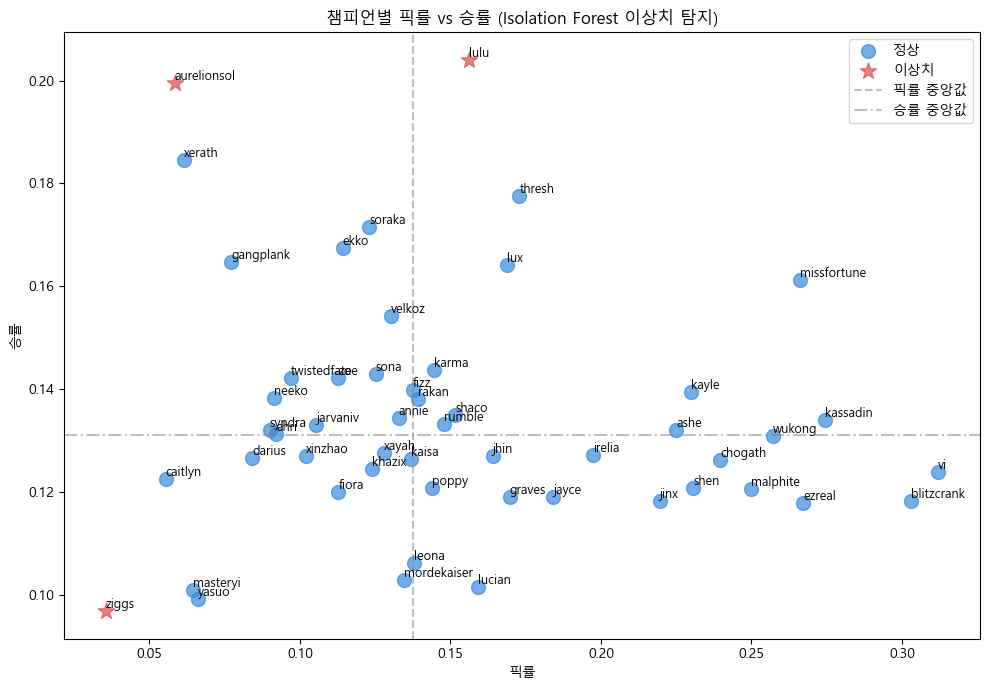

In [22]:
import matplotlib.pyplot as plt
import platform

# 한국어 폰트 설정
if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
        plt.rcParams['font.family'] = 'AppleGothic'
else:
        plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 7))

# 정상 / 이상치 분리
normal = champ_stats_valid[champ_stats_valid['anomaly'] == 1]
anomaly = champ_stats_valid[champ_stats_valid['anomaly'] == -1]

# 정상 산점도
ax.scatter(normal['pick_rate'], normal['win_rate'],
        c='#378ADD', label='정상', alpha=0.7, s=100)

# 이상치 산점도
ax.scatter(anomaly['pick_rate'], anomaly['win_rate'],
        c='#E24B4A', label='이상치', alpha=0.7, s=150, marker='*')

# 챔피언 이름 표시
for _, row in champ_stats_valid.iterrows():
        ax.annotate(row['name'],
                (row['pick_rate'], row['win_rate']),
                fontsize=9, ha='left', va='bottom')

# 기준선 (중앙값)
ax.axvline(champ_stats_valid['pick_rate'].median(),
        color='gray', linestyle='--', alpha=0.5, label='픽률 중앙값')
ax.axhline(champ_stats_valid['win_rate'].median(),
        color='gray', linestyle='-.', alpha=0.5, label='승률 중앙값')

ax.set_xlabel('픽률')
ax.set_ylabel('승률')
ax.set_title('챔피언별 픽률 vs 승률 (Isolation Forest 이상치 탐지)')
ax.legend()

plt.tight_layout()
plt.show()